# Analiza i klasyfikacja sygnału audio

<img src="ambulance.jpg" width="400" />
źródłó grafiki: https://pixabay.com/pl/photos/karetka-pogotowia-ratowa%C4%87-wsparcie-5264502/
autor: AndrzejRembowski
<img src="fire-fighters.jpg" width="400" />
źródłó grafiki: https://pixabay.com/pl/photos/stra%C5%BCacy-stra%C5%BC-po%C5%BCarna-6819677/
autor: 24488032
<img src="traffic.jpg" width="400" />
źródłó grafiki: https://pixabay.com/pl/photos/budynki-drapacz-chmur-ulica-droga-5810399/
autor: marekr

źródło danych: https://www.kaggle.com/datasets/vishnu0399/emergency-vehicle-siren-sounds

### Import bibliotek

In [1]:
import os
import wave
import pylab
import matplotlib.pyplot as plt
from scipy.io import wavfile as wav
from scipy.fftpack import fft
from tqdm.auto import tqdm
import glob
from os import path
from sklearn.model_selection import train_test_split
from sklearn import linear_model, metrics, svm, ensemble
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

### Funkcje analizy sygnału audio

In [2]:
def draw_spectrogram(wav_file: str):
    """
    funkcja wyświetlajaca wykres spektrogramu dla pliku audio
    """
    samples, frame_rate = get_wav_info(wav_file)
    pylab.figure(num=None, figsize=(15, 5))
    pylab.subplot(111) 
    pylab.axis('off')
    pylab.title("Spektrogram " + wav_file)
    pylab.xlabel('częstość')
    pylab.ylabel('czas')
    pylab.specgram(samples, Fs=frame_rate)
    
def draw_waveform(wav_file: str):
    """
    funkcja wyświetlajaca wykres amplitudy (waveform) dla pliku audio
    """
    samples, frame_rate = get_wav_info(wav_file)
    plt.figure(1, figsize=(15, 5))
    plt.title("Waveform " + wav_file)
    plt.xlabel('czas')
    plt.ylabel('amplituda')
    plt.plot(samples)
    plt.show()

def draw_fft(wav_file: str):
    """
    funkcja wyświetlajaca wykres szybkiej transformaty Fouriera (FFT) dla pliku audio
    """
    transform = get_fft(wav_file)
    length = len(transform)
    plt.figure(figsize=(15, 5))
    plt.ylim(0, 50000)
    plt.title("Fast Fourier Transform FFT " + wav_file)
    plt.xlabel('częstotliwość')
    plt.ylabel('amplituda')
    plt.plot(abs(transform[:(int(length)-1)]),'r') 
    plt.show()
     
def get_fft(wav_file: str)->list:
    """
    funkcja generujaca szybką transformate Fouriera (FFT) dla pliku audio
    """
    _, data = wav.read(wav_file)
    first_channel = data.T[0]
    normalized=[(ele/2**8.)*2-1 for ele in first_channel]
    transform = fft(normalized)
    length = len(transform)/2
    return abs(transform[:(int(length)-1)])
    
def get_wav_info(wav_file: str) -> tuple:
    """
    funkcja zwracająca próbki sygnału oraz częstotliwość próbkowania dla pliku audio
    """
    wav = wave.open(wav_file, 'r')
    frames = wav.readframes(-1)
    sound_info = pylab.fromstring(frames, 'int16')
    frame_rate = wav.getframerate()
    wav.close()
    return sound_info, frame_rate

### Analiza sygnału ambulansu

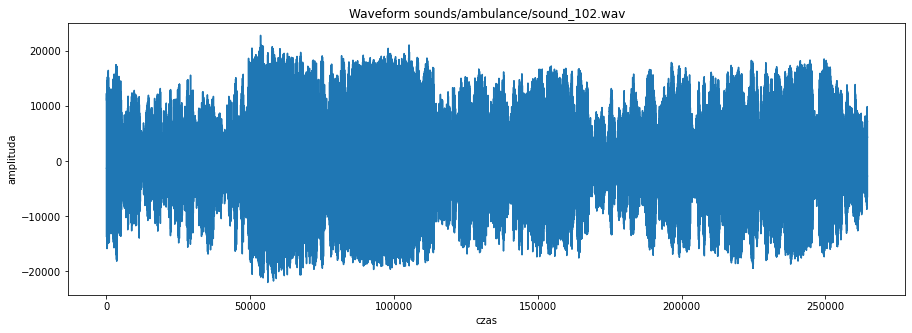

In [3]:
draw_waveform('../data/sounds/ambulance/sound_102.wav')

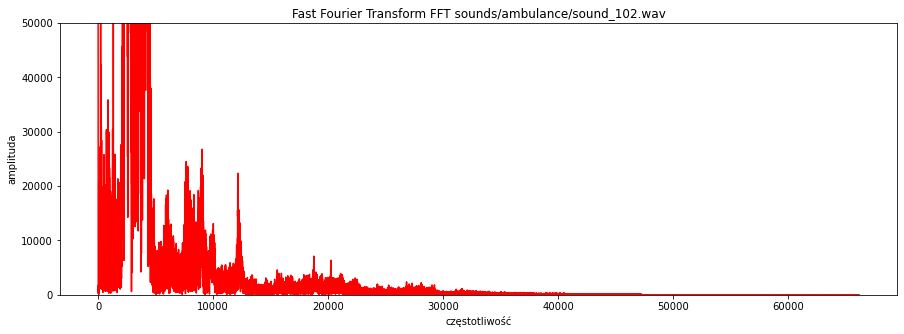

In [4]:
draw_fft('../data/sounds/ambulance/sound_102.wav')

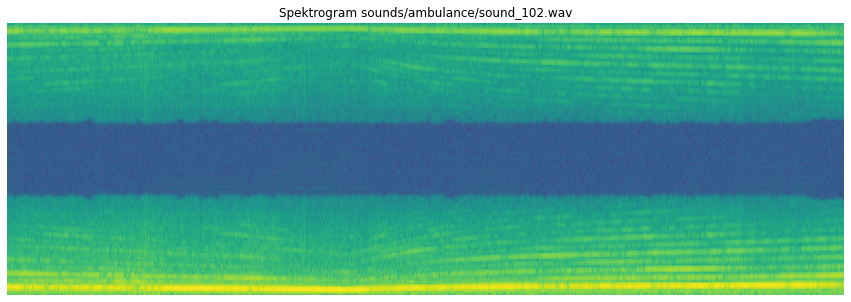

In [5]:
draw_spectrogram('../data/sounds/ambulance/sound_102.wav')

### Analiza sygnału strazy pożarnej

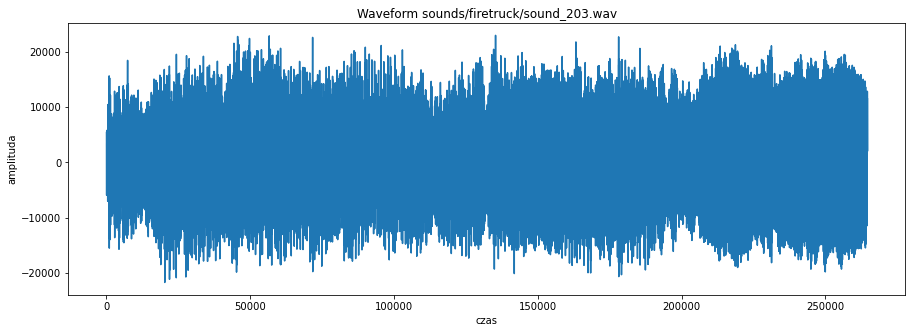

In [6]:
draw_waveform('../data/sounds/firetruck/sound_203.wav')

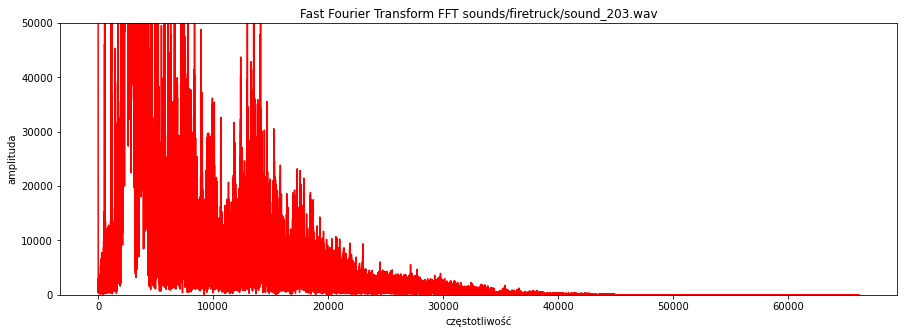

In [7]:
draw_fft('../data/sounds/firetruck/sound_203.wav')

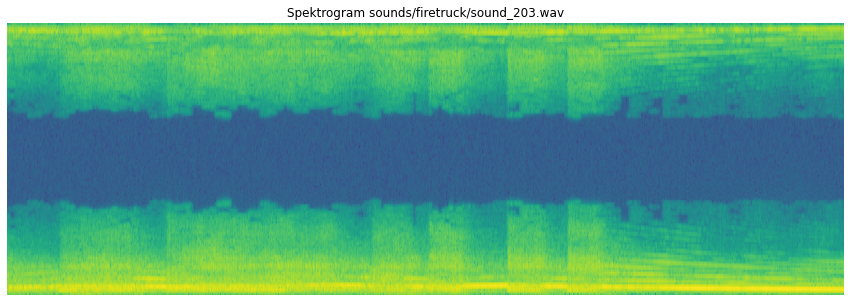

In [8]:
draw_spectrogram('../data/sounds/firetruck/sound_203.wav')

### Analiza dźwięku ruchu ulicznego

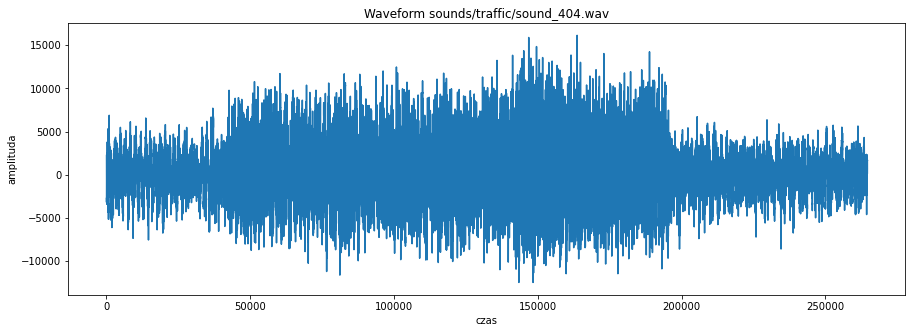

In [9]:
draw_waveform('../data/sounds/traffic/sound_404.wav')

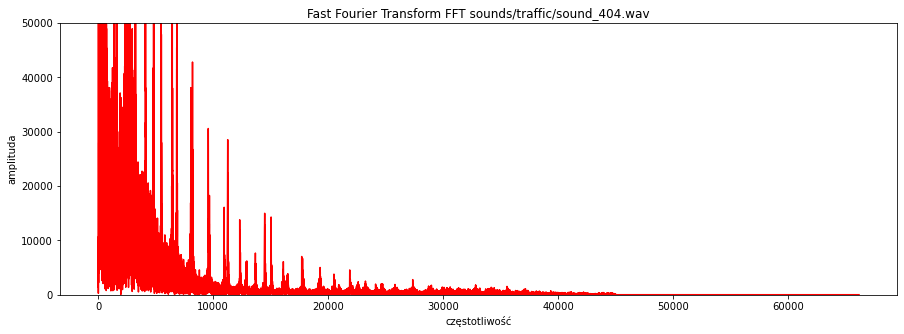

In [10]:
draw_fft('../data/sounds/traffic/sound_404.wav')

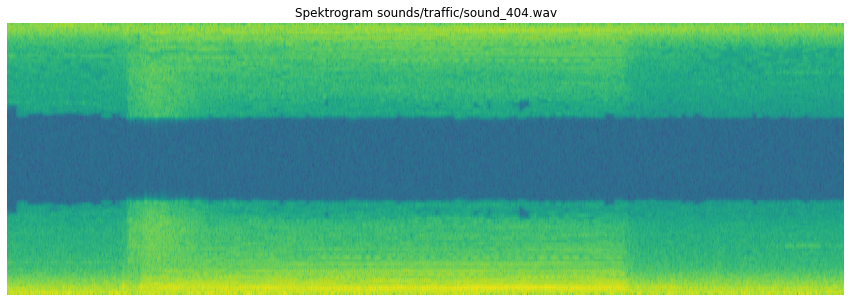

In [11]:
draw_spectrogram('../data/sounds/traffic/sound_404.wav')

### Przygotowanie zbioru treningowego (FFT) oraz etykiet

In [12]:
X = []
y = []

mapping = {
    'ambulance': 1,
    'firetruck' : 2,
    'traffic': 3
}

def reader(file):
    try:
        path_split = file.split('/')
        X.append(get_fft(file)[:50000:3])
        y.append(mapping[path_split[1]])
    except:
        pass

paths = glob.glob(path.join('', 'data/sounds/**/**'))
train = [reader(f) for f in tqdm(paths)]

  0%|          | 0/600 [00:00<?, ?it/s]

### Podział na zbiór testowy i treningowy, trenowanie i ewaluacja modelu

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12345) 


def train_model(classifier, feature_vector_train, label, feature_vector_valid):
    # trenuj model
    classifier.fit(feature_vector_train, label)
    
    # wygeneruj predykcje dla zbioru walidacyjnego
    predictions = classifier.predict(feature_vector_valid)
    
    # dokonaj ewaluacji modelu
    scores = list(metrics.precision_recall_fscore_support(predictions, y_test))
    score_vals = [
        scores[0][0],
        scores[1][0],
        scores[2][0]
    ]
    score_vals.append(metrics.accuracy_score(predictions, y_test))
    return classifier, score_vals

### Zastosowanie alternatywnych algorytmów uczenia maszynowego

In [14]:
# MODEL 1 - Regresja logistyczna
_, accuracy = train_model(linear_model.LogisticRegression(), X_train, y_train, X_test)
accuracy_compare = {'LR': accuracy}
print ("LR: ", accuracy)

LR:  [0.9210526315789473, 0.8974358974358975, 0.9090909090909091, 0.9316239316239316]


In [15]:
# MODEL 2 - Maszyna wektorów nośnych
_, accuracy = train_model(svm.SVC(), X_train, y_train, X_test)
accuracy_compare['SVM'] = accuracy
print ("SVM" , accuracy)

SVM [0.9210526315789473, 0.8974358974358975, 0.9090909090909091, 0.9316239316239316]


In [16]:
# MODEL 3 - Lasy losowe
classifier, accuracy = train_model(ensemble.RandomForestClassifier(), X_train, y_train, X_test)
accuracy_compare['RF'] = accuracy
print ("RF: ", accuracy)

RF:  [0.8947368421052632, 0.8947368421052632, 0.8947368421052632, 0.9316239316239316]


In [17]:
# MODEL 4 - Sztuczna sieć neuronowa
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10, 10, 10), max_iter=1000)
classifier, accuracy = train_model(mlp, X_train, y_train, X_test)
accuracy_compare['neural network'] = accuracy
print ("neural network" , accuracy)

neural network [0.8421052631578947, 0.8888888888888888, 0.8648648648648649, 0.5982905982905983]


### Porównanie modeli

{'LR': [0.9210526315789473, 0.8974358974358975, 0.9090909090909091, 0.9316239316239316], 'SVM': [0.9210526315789473, 0.8974358974358975, 0.9090909090909091, 0.9316239316239316], 'RF': [0.8947368421052632, 0.8947368421052632, 0.8947368421052632, 0.9316239316239316], 'neural network': [0.8421052631578947, 0.8888888888888888, 0.8648648648648649, 0.5982905982905983]}


<AxesSubplot:>

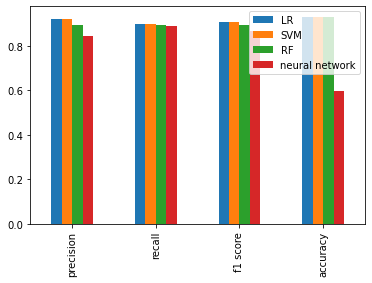

In [18]:
# porównanie modeli
print(accuracy_compare)
df_compare = pd.DataFrame(accuracy_compare, index = ['precision', 'recall', 'f1 score', 'accuracy'])
df_compare.plot(kind='bar')

### Sprawdź porzewidywania modelu w praktyce

In [19]:
fft_ambulance = get_fft('../data/sounds/ambulance/sound_102.wav')[:50000:3]
fft_firetruck = get_fft('../data/sounds/firetruck/sound_203.wav')[:50000:3]
fft_traffic = get_fft('../data/sounds/traffic/sound_404.wav')[:50000:3]
classifier.predict([fft_ambulance,fft_firetruck, fft_traffic])

array([1, 2, 2])